<h1>🫀 Heart Disease Prediction </h1>

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve,recall_score

### Heart Disease Dataset Feature Description

| Feature    | Description |
|------------|-------------|
| **age**     | Age of the patient in years |
| **sex**     | Gender of the patient (0 = male, 1 = female) |
| **cp**      | Chest pain type:<br> 0: Typical angina <br> 1: Atypical angina <br> 2: Non-anginal pain <br> 3: Asymptomatic |
| **trestbps**| Resting blood pressure in mm Hg |
| **chol**    | Serum cholesterol in mg/dl |
| **fbs**     | Fasting blood sugar level, categorized as above 120 mg/dl (1 = true, 0 = false) |
| **restecg** | Resting electrocardiographic results:<br> 0: Normal <br> 1: ST-T wave abnormality <br> 2: Probable/definite left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved during a stress test |
| **exang**   | Exercise-induced angina (1 = yes, 0 = no) |
| **oldpeak** | ST depression induced by exercise relative to rest |
| **slope**   | Slope of the peak exercise ST segment:<br> 0: Upsloping <br> 1: Flat <br> 2: Downsloping |
| **ca**      | Number of major vessels (0–4) colored by fluoroscopy |
| **thal**    | Thalium stress test result:<br> 0: Normal <br> 1: Fixed defect <br> 2: Reversible defect <br> 3: Not described |
| **target**  | Heart disease status (0 = no disease, 1 = presence of disease) |


## 📥 Load Dataset

In [75]:
df=pd.read_csv('./dataset/heart.csv')
df
               

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## 🔍 Exploratory Data Analysis (EDA)

In [76]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [77]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

In [78]:
# Check for missing values
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 📈 Distribution of Important Features

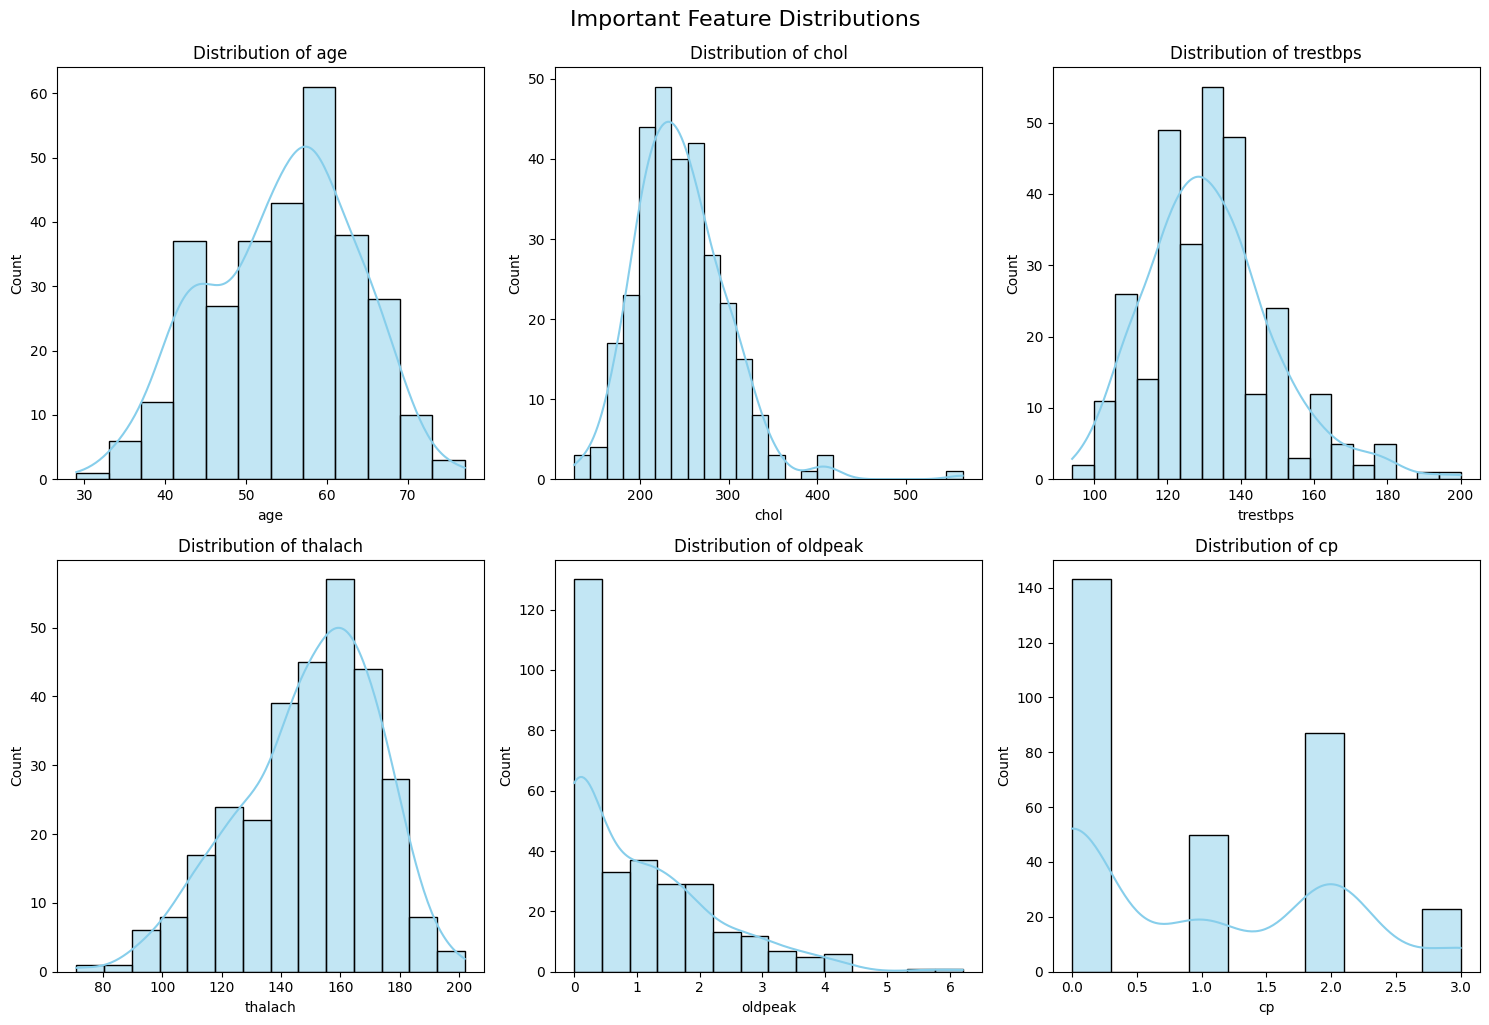

In [79]:
important_features = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'cp']

plt.figure(figsize=(15, 10))
for i, col in enumerate(important_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.suptitle('Important Feature Distributions', y=1.02, fontsize=16)
plt.show()


### 📦 Boxplots for Outlier Detection

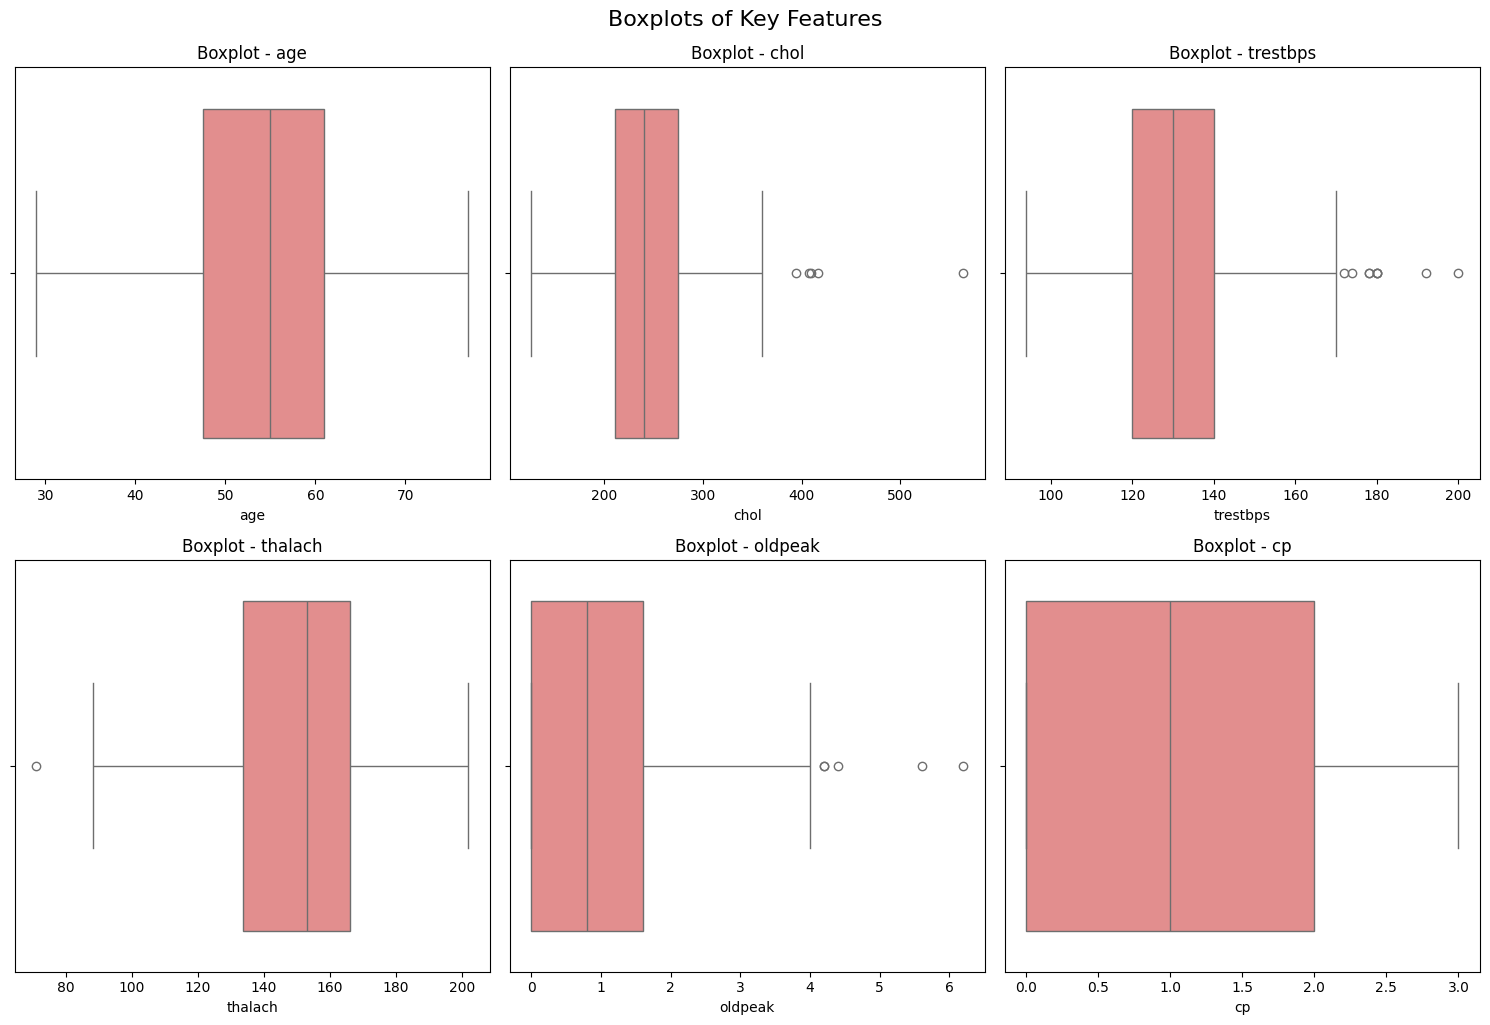

In [80]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(important_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot - {col}')
plt.tight_layout()
plt.suptitle('Boxplots of Key Features', y=1.02, fontsize=16)
plt.show()

### 🔗 Correlation Heatmap

C:\Users\muham\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


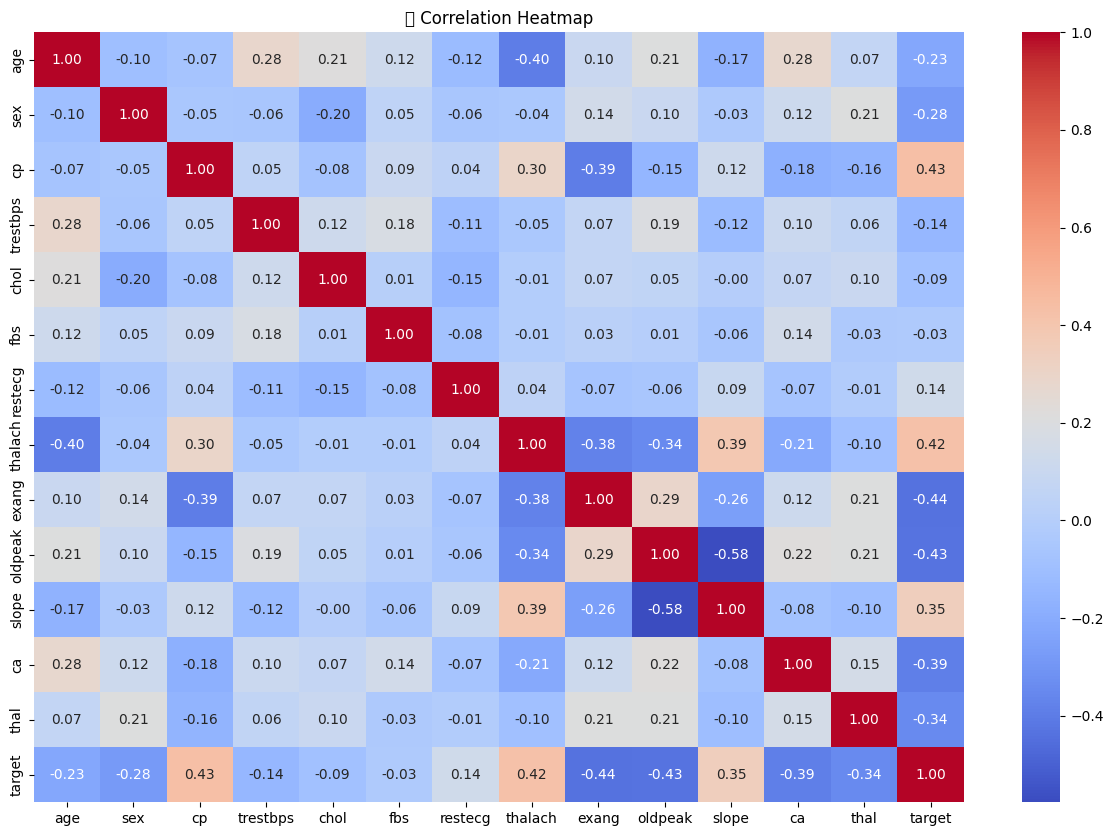

In [81]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('🔗 Correlation Heatmap')
plt.show()

### 🧪 Pairplot by Target

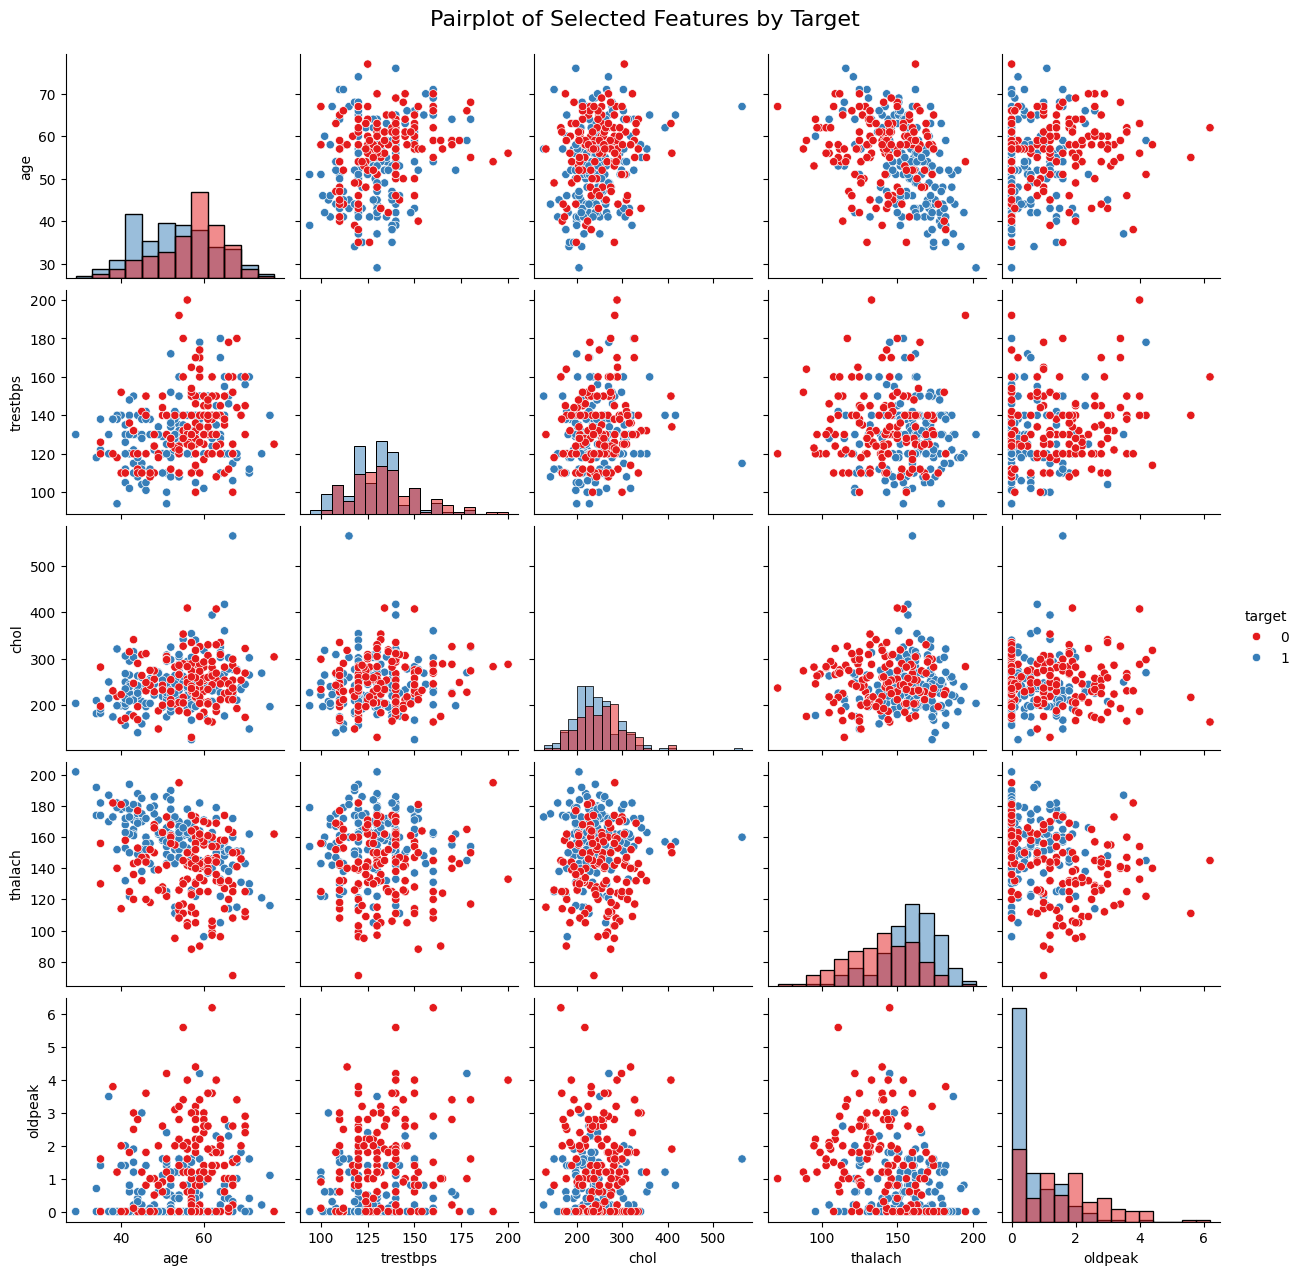

In [82]:
# Pairplot with selected features to reduce clutter
selected_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(df[selected_features], hue='target', palette='Set1', diag_kind='hist')
plt.suptitle("Pairplot of Selected Features by Target", y=1.02, fontsize=16)
plt.show()


## 🧼 Outlier Handling using IQR

In [ ]:
# Cap and floor outliers using IQR
def cap_floor_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower, upper)  # Caps and floors outliers
    return data

for col in ['trestbps', 'chol', 'oldpeak']:
    df = cap_floor_outliers_iqr(df, col)

## 🔢 One-Hot Encoding for Categorical Features

In [84]:
# One-hot encoding for categorical features
df_encoded = pd.get_dummies(df, columns=['cp', 'thal', 'slope'], drop_first=True)

## 🧠 Feature Selection

In [85]:
# 1. Correlation with Target
corr_scores = df_encoded.corr()['target'].abs().sort_values(ascending=False)
top_corr_features = corr_scores[1:11].index.tolist()  # skip 'target' itself
print("Top features by correlation:", top_corr_features)

Top features by correlation: ['thal_2', 'thal_3', 'oldpeak', 'exang', 'thalach', 'slope_2', 'ca', 'slope_1', 'sex', 'cp_2']


In [86]:
# 2. Chi-Square Test (requires non-negative features)
X_all = df_encoded.drop("target", axis=1)
y_all = df_encoded["target"]
X_chi2 = X_all.copy()
X_chi2 = X_chi2.apply(lambda x: x if x.min() >= 0 else x - x.min())  # make non-negative
chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(X_chi2, y_all)
chi2_features = X_chi2.columns[chi2_selector.get_support()].tolist()
print("Top features by Chi2:", chi2_features)

Top features by Chi2: ['age', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'thal_2', 'thal_3', 'slope_1', 'slope_2']


## 🎯 Data Preparation for Modeling

In [87]:
combined_features = list(set(top_corr_features + chi2_features))
print("\nFinal combined selected features (no duplicates):")
print(combined_features)
                         


Final combined selected features (no duplicates):
['ca', 'thal_3', 'exang', 'cp_2', 'age', 'thalach', 'slope_2', 'chol', 'slope_1', 'sex', 'oldpeak', 'thal_2']


## 🧪 Train-Test Split

In [88]:
x=df_encoded[combined_features]
y=df_encoded['target']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 📐 Stratified K-Fold Cross-Validation

In [89]:
# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

## 🌳 Random Forest Classifier

In [90]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample']
}


rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=skf, scoring='accuracy',verbose=2,n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
print("Random Forest Best Params:", rf_grid.best_params_)



Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Random Forest Best Params: {'class_weight': 'balanced', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


### 📊 Evaluation - Random Forest

In [91]:
# Evaluation
rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf_prob))

# Stratified CV score
rf_scores = cross_val_score(rf_best, X_train, y_train, cv=skf, scoring='accuracy')
print("Random Forest Stratified CV Accuracy:", rf_scores.mean())

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.84        26
           1       0.89      0.81      0.85        31

    accuracy                           0.84        57
   macro avg       0.84      0.85      0.84        57
weighted avg       0.85      0.84      0.84        57

ROC AUC Score: 0.9230769230769231
Random Forest Stratified CV Accuracy: 0.8070175438596493


### 📈 ROC Curve - Random Forest

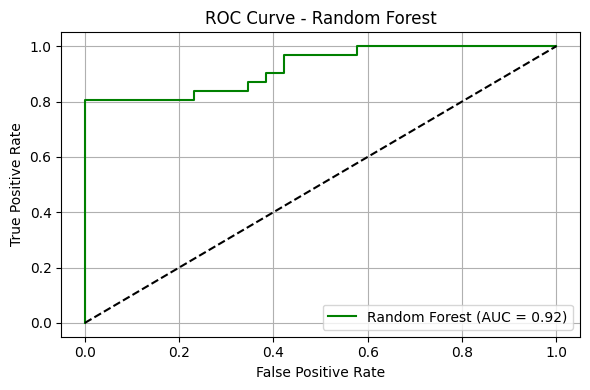

In [92]:
# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(roc_auc_score(y_test, rf_prob)), color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 🚀 Gradient Boosting Classifier

In [93]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb, gb_params, cv=skf, scoring='accuracy',verbose=2,n_jobs=-1)
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_
print("Gradient Boosting Best Params:", gb_grid.best_params_)

Fitting 3 folds for each of 1458 candidates, totalling 4374 fits


C:\Users\muham\AppData\Roaming\Python\Python312\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}


### 📊 Evaluation - Gradient Boosting

In [94]:
# Evaluation
gb_pred = gb_best.predict(X_test)
gb_prob = gb_best.predict_proba(X_test)[:, 1]

print("Gradient Boosting Classification Report:\n", classification_report(y_test, gb_pred))
print("ROC AUC Score:", roc_auc_score(y_test, gb_prob))

# Stratified CV score
gb_scores = cross_val_score(gb_best, X_train, y_train, cv=skf, scoring='accuracy')
print("Gradient Boosting Stratified CV Accuracy:", gb_scores.mean())

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77        26
           1       0.81      0.81      0.81        31

    accuracy                           0.79        57
   macro avg       0.79      0.79      0.79        57
weighted avg       0.79      0.79      0.79        57

ROC AUC Score: 0.892059553349876
Gradient Boosting Stratified CV Accuracy: 0.8157894736842106


### 📈 ROC Curve - Gradient Boosting


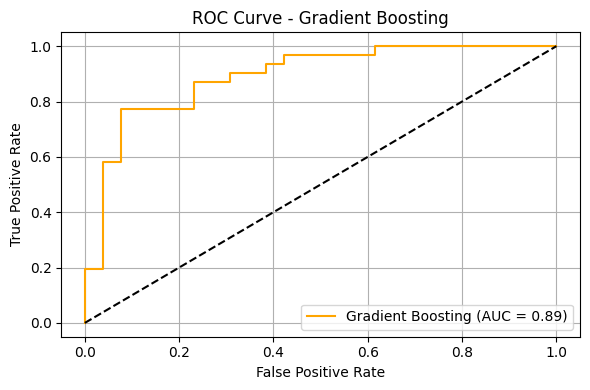

In [95]:
# ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting (AUC = {:.2f})'.format(roc_auc_score(y_test, gb_prob)), color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## ⚡ XGBoost Classifier

In [96]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2],
    'scale_pos_weight': [1, 2]  # Useful for imbalanced classes
}


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb, xgb_params, cv=skf, scoring='accuracy',verbose=2,n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
print("XGBoost Best Params:", xgb_grid.best_params_)

Fitting 3 folds for each of 5832 candidates, totalling 17496 fits
XGBoost Best Params: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 2, 'scale_pos_weight': 2, 'subsample': 1.0}


### 📊 Evaluation - XGBoost Classifier


In [97]:
# Evaluation
xgb_pred = xgb_best.predict(X_test)
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]

print("XGBoost Classification Report:\n", classification_report(y_test, xgb_pred))
print("ROC AUC Score:", roc_auc_score(y_test, xgb_prob))

# Stratified CV score
xgb_scores = cross_val_score(xgb_best, X_train, y_train, cv=skf, scoring='accuracy')
print("XGBoost Stratified CV Accuracy:", xgb_scores.mean())

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.65      0.74        26
           1       0.76      0.90      0.82        31

    accuracy                           0.79        57
   macro avg       0.80      0.78      0.78        57
weighted avg       0.80      0.79      0.79        57

ROC AUC Score: 0.9205955334987593
XGBoost Stratified CV Accuracy: 0.8201754385964911


### 📈 ROC Curve - XGBoost Classifier


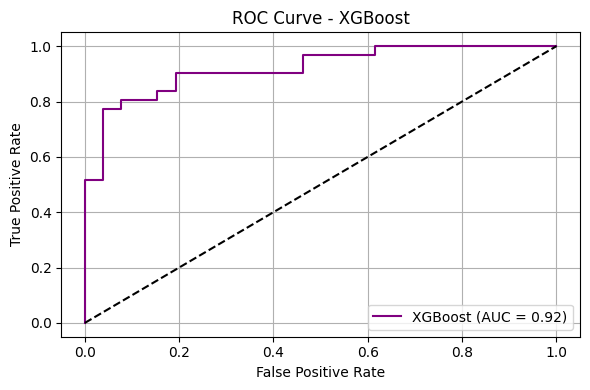

In [98]:
# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = {:.2f})'.format(roc_auc_score(y_test, xgb_prob)), color='purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

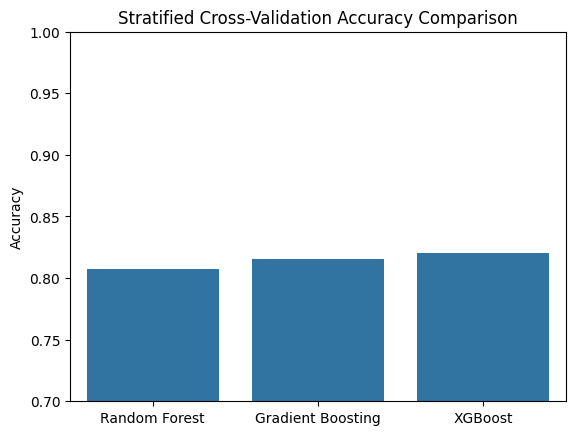

In [99]:
# Accuracy Bar Plot
acc_dict = {
    'Random Forest': rf_scores.mean(),
    'Gradient Boosting': gb_scores.mean(),
    'XGBoost': xgb_scores.mean()
}

sns.barplot(x=list(acc_dict.keys()), y=list(acc_dict.values()))
plt.title("Stratified Cross-Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.show()

## 🏆 Model Comparison & Final Results

C:\Users\muham\AppData\Local\Temp\ipykernel_14440\3983085309.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_acc_dict.keys()), y=list(test_acc_dict.values()), palette='coolwarm')


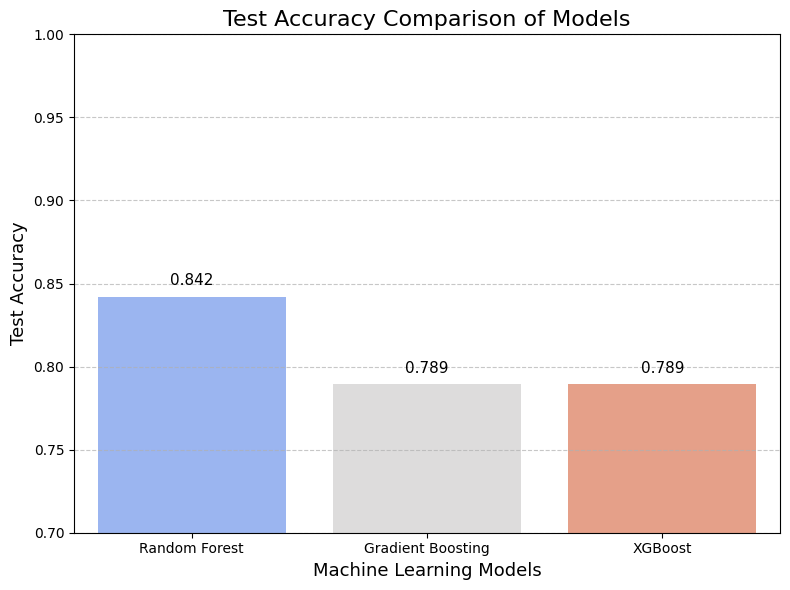

In [100]:
# Calculate test accuracy for each model
rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

# Dictionary to store accuracies
test_acc_dict = {
    'Random Forest': rf_acc,
    'Gradient Boosting': gb_acc,
    'XGBoost': xgb_acc
}

# Plotting
plt.figure(figsize=(8, 6))
sns.barplot(x=list(test_acc_dict.keys()), y=list(test_acc_dict.values()), palette='coolwarm')

# Annotate accuracy values on top of each bar
for i, value in enumerate(test_acc_dict.values()):
    plt.text(i, value + 0.005, f'{value:.3f}', ha='center', va='bottom', fontsize=11)

# Customize the plot
plt.title("Test Accuracy Comparison of Models", fontsize=16)
plt.xlabel("Machine Learning Models", fontsize=13)
plt.ylabel("Test Accuracy", fontsize=13)
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

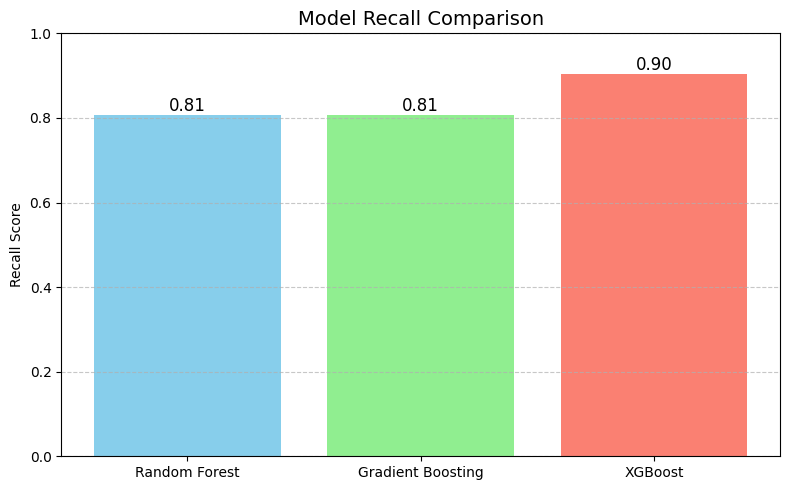

In [102]:
rf_recall = recall_score(y_test, rf_pred)
gb_recall = recall_score(y_test, gb_pred)
xgb_recall = recall_score(y_test, xgb_pred)


models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
recalls = [rf_recall, gb_recall, xgb_recall]

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(models, recalls, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)
plt.title('Model Recall Comparison', fontsize=14)
plt.ylabel('Recall Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()